<a href="https://colab.research.google.com/github/Yasir-Aladwani/medical-insurance-random-forest-project/blob/main/medical_insurance_cost_prediction_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Insurance Cost Prediction Using Random Forest
This project analyzes the factors affecting medical insurance charges using exploratory data analysis and machine learning. A Random Forest regression model is used to predict insurance costs based on demographic and lifestyle features such as age, BMI, and smoking status.

##  Import libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [8]:
# Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

##  Load dataset

In [9]:
df = pd.read_csv("/content/insurance.csv")

##  Display basic information

In [10]:
print("First 5 rows:")
print(df.head())
print("\nShape of dataset:", df.shape)

First 5 rows:
   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86

Shape of dataset: (1338, 7)


In [11]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')


In [12]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [13]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


In [14]:
print("\nDupicated values:")
print(df.duplicated().sum())


Dupicated values:
1


In [15]:
# Remove duplicate rows
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [16]:
print("\nDescriptive statistics:")
print(df.describe())


Descriptive statistics:
               age          bmi     children      expenses
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.665520     1.095737  13279.121638
std      14.044333     6.100664     1.205571  12110.359657
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4746.340000
50%      39.000000    30.400000     1.000000   9386.160000
75%      51.000000    34.700000     2.000000  16657.720000
max      64.000000    53.100000     5.000000  63770.430000


##  Data Understanding

In [17]:
print("\nUnique values in categorical columns:")
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


Unique values in categorical columns:

sex:
sex
male      675
female    662
Name: count, dtype: int64

smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


## EDA Question 1:
## What is the distribution of medical insurance expenses?

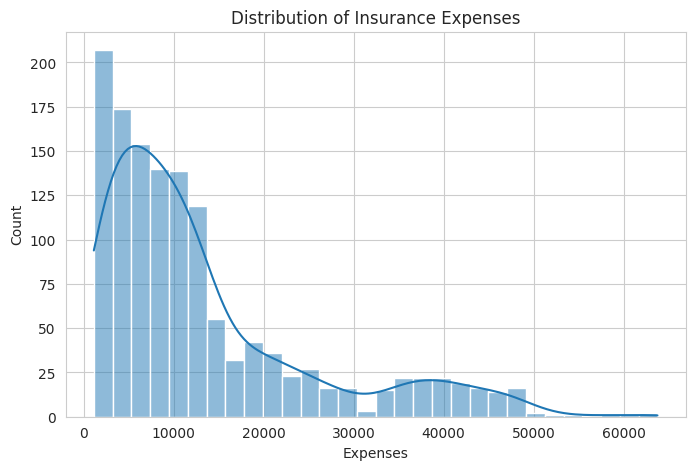

In [18]:
plt.figure()
sns.histplot(df["expenses"], bins=30, kde=True)
plt.title("Distribution of Insurance Expenses")
plt.xlabel("Expenses")
plt.ylabel("Count")
plt.show()

**Insight:**

- The distribution of medical insurance charges is right-skewed (positively skewed).
- Most individuals have relatively low medical costs, while a smaller number of people experience very high charges.
________________________________________________________________________________

## EDA Question 2:
## Does age affect insurance expenses?

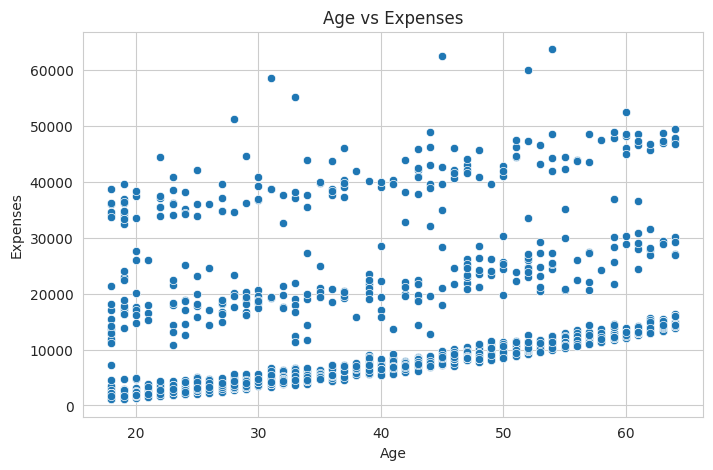

In [19]:
plt.figure()
sns.scatterplot(data=df, x="age", y="expenses")
plt.title("Age vs Expenses")
plt.xlabel("Age")
plt.ylabel("Expenses")
plt.show()

**Insight:**

- The scatter plot shows a positive relationship between age and medical
charges, suggesting that healthcare costs generally increase as individuals grow older.

- The plot also shows distinct cost clusters, suggesting that other factors such as smoking status may strongly influence insurance charges.
________________________________________________________________________________

## EDA Question 3:
## Do smokers pay higher insurance expenses?

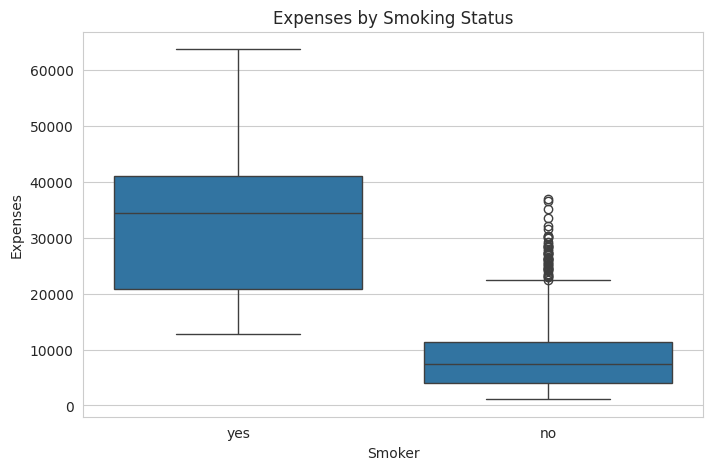


Average expenses by smoking status:
smoker
no      8440.660461
yes    32050.231971
Name: expenses, dtype: float64


In [20]:
plt.figure()
sns.boxplot(data=df, x="smoker", y="expenses")
plt.title("Expenses by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Expenses")
plt.show()

smoker_mean = df.groupby("smoker")["expenses"].mean()
print("\nAverage expenses by smoking status:")
print(smoker_mean)

**Insight:**
- The boxplot clearly shows that smokers have substantially higher insurance charges than non-smokers.
- This suggests that smoking is one of the strongest factors affecting medical costs in the dataset.
________________________________________________________________________________

## EDA Question 4:
## Does BMI affect insurance expenses?

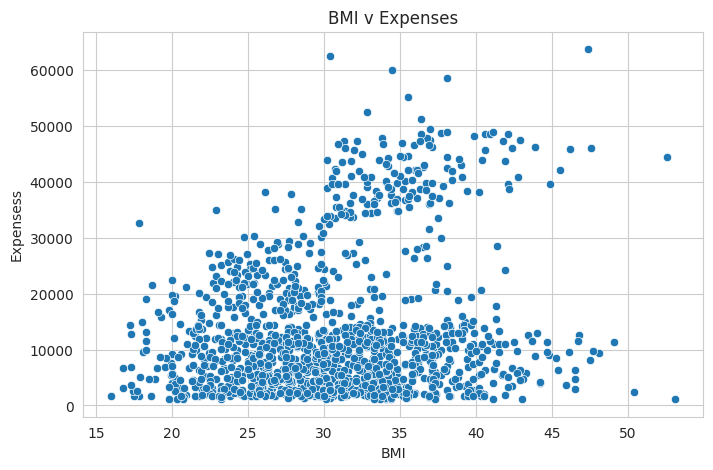

In [21]:
plt.figure()
sns.scatterplot(data=df, x="bmi", y="expenses")
plt.title("BMI v Expenses")
plt.xlabel("BMI")
plt.ylabel("Expensess")
plt.show()

**Insight:**
- The scatter plot suggests that higher BMI values are associated with increased insurance charges, although the relationship is not perfectly linear.
- The presence of high-cost clusters suggests that BMI alone does not explain the variation in charges, and other factors such as smoking likely play a stronger role.
________________________________________________________________________________

## EDA Question 5:
## Are there outliers in medical insurance expenses?

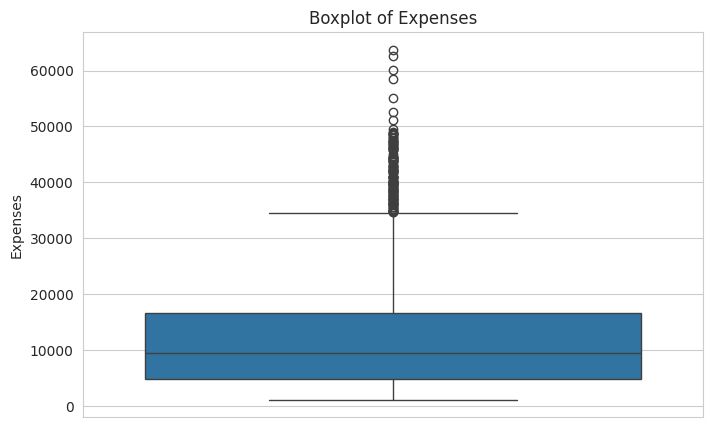


Number of outliers in expenses: 139


In [22]:
plt.figure()
sns.boxplot(y=df["expenses"])
plt.title("Boxplot of Expenses")
plt.ylabel("Expenses")
plt.show()

Q1 = df["expenses"].quantile(0.25)
Q3 = df["expenses"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["expenses"] < lower_bound) | (df["expenses"] > upper_bound)]
print("\nNumber of outliers in expenses:", outliers.shape[0])

**Insight:**
- These outliers were retained since they represent real-world high medical expenses rather than incorrect data.

## EDA Question 6:
## Which variable is most associated with charges?

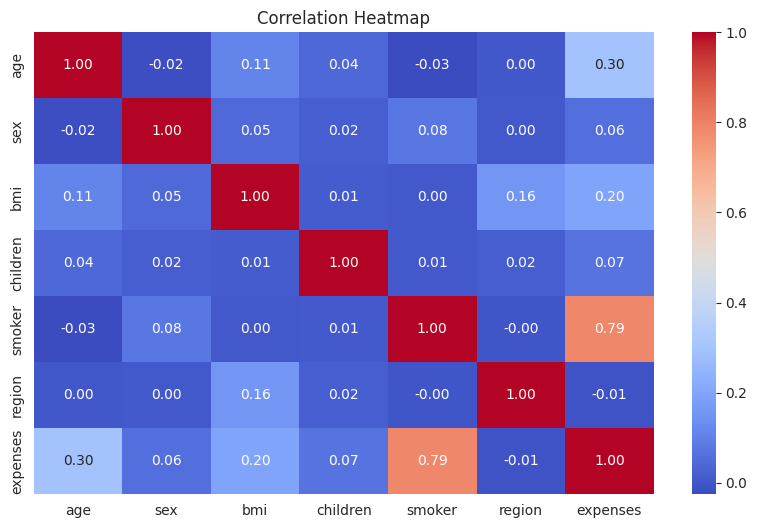


Correlation with Expenses:
expenses    1.000000
smoker      0.787234
age         0.298308
bmi         0.198637
children    0.067389
sex         0.058045
region     -0.006547
Name: expenses, dtype: float64


In [23]:
# Copy dataframe for encoding
df_encoded = df.copy()

# Encode categorical columns
label_encoders = {}
for col in df_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Correlation matrix
corr = df_encoded.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print("\nCorrelation with Expenses:")
print(corr["expenses"].sort_values(ascending=False))

**Insight:**
- Smoking is the strongest predictor of medical insurance costs.
- Older individuals tend to have higher medical costs.
- Higher BMI is associated with moderately higher charges.
- Gender, region, and number of children have relatively weak effects on insurance costs.
________________________________________________________________________________

## Model: Random Forest Regression

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.  
It works well for tabular datasets and can capture nonlinear relationships between features and the target variable (insurance charges).

In [35]:
# Features and target
X = df_encoded.drop("expenses", axis=1)
y = df_encoded["expenses"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
rf_model = RandomForestRegressor(random_state=42, n_estimators=200)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [37]:
# Predict using Random Forest
y_pred_rf = rf_model.predict(X_test)

# Performance Metrics for Random Forest only
metrics_df = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [mean_absolute_error(y_test, y_pred_rf)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_rf))],
    "R2": [r2_score(y_test, y_pred_rf)]
})

metrics_df

,Model,MAE,RMSE,R2
0,Random Forest,2545.303347,4618.152817,0.883937


### Feature Importance Analysis (Random Forest)

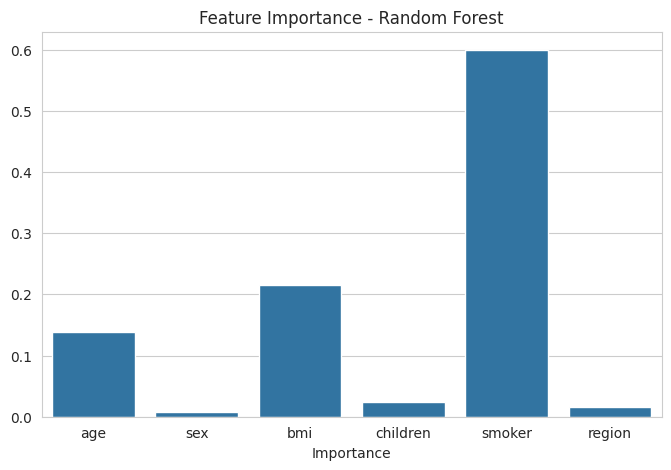


Most important features:
age         0.138135
sex         0.007612
bmi         0.214560
children    0.023798
smoker      0.599299
region      0.016595
dtype: float64


In [38]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))
sns.barplot(x=feature_importance.index, y=feature_importance.values)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

print("\nMost important features:")
print(feature_importance)

**Insight:**
- The feature importance analysis shows that smoking status, BMI, and age are the most influential factors affecting medical insurance charges.

## Performance Visualization

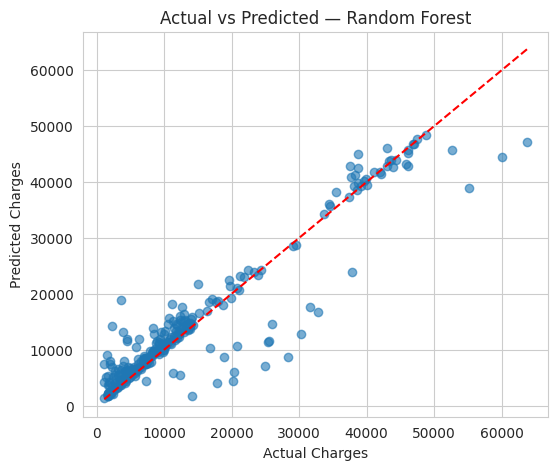

In [39]:
# Actual vs Predicted — Random Forest
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted — Random Forest")

plt.show()

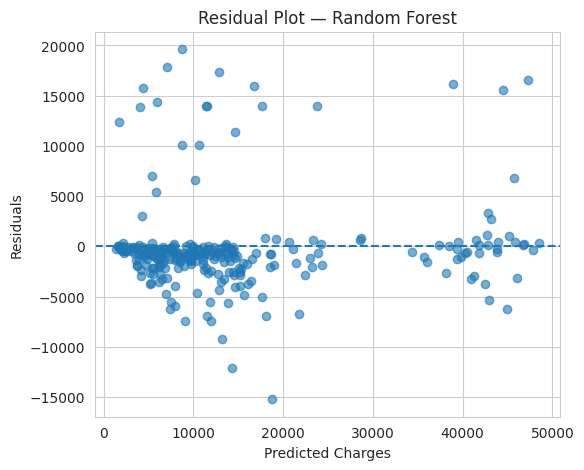

In [40]:
# Residual Plot — Random Forest
rf_residuals = y_test - y_pred_rf

plt.figure(figsize=(6,5))

plt.scatter(y_pred_rf, rf_residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot — Random Forest")

plt.show()

## Conclusion

In this project, a Random Forest Regression model was used to predict medical insurance charges based on demographic and lifestyle features. The model achieved strong performance with an R² score of about 0.88, showing its ability to capture complex relationships in the data. The results highlight that smoking status, BMI, and age are the most important factors influencing insurance costs.